SETUP THE NWB DATA

In [1]:
import sys
sys.path.insert(0, '/code/src')

import glob
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from datetime import datetime
from scipy.stats import linregress

sns.set_theme(context='talk', style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 'medium'
plt.rcParams['axes.titlelocation'] = 'left'

sns.set_context('talk')
pd.set_option('display.max_columns', None)

DATA_ROOT = '/data/dynamicrouting_datacube'

SESSION_NUMBER = 11        # <-- switch session

# Read all the session in data and select
session_paths = sorted(glob.glob('%s/*/*.nwb.zarr' % DATA_ROOT))
session_ids = [os.path.basename(p).replace('.nwb.zarr', '') for p in session_paths]
print('%d sessions available' % len(session_ids))
for position, available_id in enumerate(session_ids):
    print('  %2d  %s' % (position, available_id))

session_id = session_ids[SESSION_NUMBER]
nwb_path = session_paths[SESSION_NUMBER]

# Cache check: re-running this cell for the same session does not reload the file
if 'session_cache' not in globals():
    session_cache = {}
if session_id not in session_cache:
    print('\nloading %s ...' % session_id)
    session_cache[session_id] = pynwb.read_nwb(nwb_path)
else:
    print('\nusing cached %s' % session_id)

session = session_cache[session_id]
trials = session.trials[:]
print('Selected session %d: %s, %d trials' % (SESSION_NUMBER, session_id, len(trials)))

12 sessions available
   0  662892_2023-08-24
   1  664851_2023-11-16
   2  667252_2023-09-28
   3  708016_2024-04-29
   4  712815_2024-05-22
   5  713655_2024-08-09
   6  714748_2024-06-24
   7  715710_2024-07-16
   8  741137_2024-10-10
   9  742903_2024-10-23
  10  743199_2024-12-05
  11  759434_2025-02-04

loading 759434_2025-02-04 ...


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


Selected session 11: 759434_2025-02-04, 545 trials


SETUP THE FUNCTIONS TO SAVE DATA AND FIGURES

In [2]:
SCRATCH_DIR = '/scratch/rt_analysis'
FIGURE_DIR = os.path.join(SCRATCH_DIR, 'figures')
DATA_DIR = os.path.join(SCRATCH_DIR, 'data')
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

def save_figure(fig, figure_name, session=None):
    """Save a figure as <session_id>__<figure_name>.png"""
    session = session or session_id
    fig.text(0.995, 0.005, session, ha='right', va='bottom', fontsize=7, color='0.5')
    out_path = os.path.join(FIGURE_DIR, '%s__%s.png' % (session, figure_name))
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    print('saved %s' % out_path)
    return out_path

def save_table(dataframe, table_name, session=None):
    """Save a dataframe as <session_id>__<table_name>.csv"""
    session = session or session_id
    out = dataframe.copy()
    out.insert(0, 'session_id', session)
    out_path = os.path.join(DATA_DIR, '%s__%s.csv' % (session, table_name))
    out.to_csv(out_path, index=False)
    print('saved %s' % (out_path))
    return out_path

SETUP THE METADATA

In [3]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = 'api.allenneuraldynamics.org'
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(host=API_GATEWAY_HOST, version='v2', database=DATABASE, collection=COLLECTION)

aggregate = [
    {'$match': {
        'data_description.project_name': 'Dynamic Routing',
        'data_description.data_level': 'derived',
        'processing.data_processes': {'$elemMatch': {
            'process_type': 'File format conversion',
            'start_date_time': {'$regex': '^2026-08-04'}}}}},
    {'$project': {
        'name': 1,
        'subject_id': '$data_description.subject_id',
        'genotype': '$subject.subject_details.genotype',
        'date_of_birth': '$subject.subject_details.date_of_birth',
        'sex': '$subject.subject_details.sex',
        'session_start_time': '$acquisition.acquisition_start_time',
        'session_end_time': '$acquisition.acquisition_end_time',
        'stimulus_epochs': '$acquisition.stimulus_epochs',
        'project_name': '$data_description.project_name',
        'modality': '$data_description.modalities.name',
        'targeted_structure': ('$acquisition.data_streams.configurations.probes'
                               '.primary_targeted_structure.name')}},
]

records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)
for r in records:
    dr = next((e for e in r.get('stimulus_epochs', [])
               if e.get('stimulus_name') == 'DynamicRouting1'), None)
    r['dr_performance'] = dr['performance_metrics'] if dr else None

metadata_df = pd.DataFrame(records)
metadata_df['trials_total'] = metadata_df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
metadata_df['trials_rewarded'] = metadata_df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)

# Check the metadata structure
this_session_row = metadata_df[metadata_df.name.str.contains(session_id, na=False)]
print('Metadata trials_total: %s, NWB trials: %d' % (this_session_row.trials_total.values, len(trials)))
print('Metadata trials_rewarded: %s, NWB is_rewarded: %d' % (this_session_row.trials_rewarded.values, trials.is_rewarded.sum()))
metadata_df.head(3)

Metadata trials_total: [545], NWB trials: 545
Metadata trials_rewarded: [142], NWB is_rewarded: 144


,_id,name,subject_id,genotype,date_of_birth,sex,session_start_time,session_end_time,stimulus_epochs,project_name,modality,targeted_structure,dr_performance,trials_total,trials_rewarded
0,c5bc8e0e-81ee-4e52-a7b6-90089b0dfc5f,ecephys_742903_2024-10-23_14-12-23_nwb_2026-08...,742903,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2024-05-16,Female,2024-10-23 14:12:23-07:00,2024-10-23 16:15:54.652646-07:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Primary somatosensory area], [Caudoputamen]...","{'object_type': 'Performance metrics', 'output...",489,124
1,7f603b00-8b9f-4a66-8b9d-1d9ed27b40d4,ecephys_743199_2024-12-05_12-42-34_nwb_2026-08...,743199,VGAT-ChR2-YFP/wt,2024-05-18,Female,2024-12-05 12:42:34-08:00,2024-12-05 14:39:42.445214-08:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Periaqueductal gray], [Red nucleus], [Red n...","{'object_type': 'Performance metrics', 'output...",490,132
2,66dc0f20-45dc-4a65-ac3a-0a04ac0e1df4,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,Female,2023-08-24 14:28:28-07:00,2023-08-24 16:28:14.588745-07:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Piriform area], [root]]]","{'object_type': 'Performance metrics', 'output...",476,123


UNITS QUALITY CONTROL

In [4]:
units_table = session.units[:]
print('This session has %d units before quality control' % len(units_table))

# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]

this_structure_units_table = good_units[good_units.structure == 'MOs']
print('%d good units in MOs' % len(this_structure_units_table))

This session has 2285 units before quality control
196 good units in MOs


SANITY CHECKS:

Is the first lick equal to response time?

In [5]:
licks = session.processing['behavior']['licks'][:]

lick_time_array = np.sort(licks['timestamps'].values.astype(float))
print('Number of licks: %d' % (lick_time_array.size))

# distance from each scored response to the nearest recorded lick
response_time_array = trials.loc[trials.is_response, 'response_time'].values.astype(float)
insert_index_array = np.clip(np.searchsorted(lick_time_array, response_time_array), 1, lick_time_array.size - 1)
nearest_offset_array = np.minimum(
    np.abs(response_time_array - lick_time_array[insert_index_array - 1]),
    np.abs(response_time_array - lick_time_array[insert_index_array]))

print('\n|response_time - nearest lick|: median %.2f ms, max %.2f ms'
      % (np.median(nearest_offset_array) * 1e3, nearest_offset_array.max() * 1e3))

Number of licks: 2353

|response_time - nearest lick|: median 0.00 ms, max 0.00 ms


How is the trial structure?

In [6]:
# Trial structure
print('Trial structure: go %d + nogo %d + catch %d = %d, total trials %d'
      % (trials.is_go.sum(), trials.is_nogo.sum(), trials.is_catch.sum(),
         trials.is_go.sum() + trials.is_nogo.sum() + trials.is_catch.sum(),
         len(trials)))
print('hit %d + miss %d = go %d'
      % (trials.is_hit.sum(), trials.is_miss.sum(), trials.is_go.sum()))
print('false alarm %d + correct reject %d = nogo %d'
      % (trials.is_false_alarm.sum(), trials.is_correct_reject.sum(),
         trials.is_nogo.sum()))

# Responses types
n_catch_response = (trials.is_catch & trials.is_response).sum()
print('\nhit %d + false alarm %d + catch response %d = %d, is_response %d'
      % (trials.is_hit.sum(), trials.is_false_alarm.sum(), n_catch_response,
         trials.is_hit.sum() + trials.is_false_alarm.sum() + n_catch_response,
         trials.is_response.sum()))

# Response window
window_start_offset = trials.response_window_start_time - trials.stim_start_time
window_stop_offset = trials.response_window_stop_time - trials.stim_start_time
print('\nresponse window start offset: %.4f to %.4f s (median %.4f)'
      % (window_start_offset.min(), window_start_offset.max(),
         window_start_offset.median()))
print('response window stop  offset: %.4f to %.4f s (median %.4f)'
      % (window_stop_offset.min(), window_stop_offset.max(),
         window_stop_offset.median()))

# Save outcome trial structure
trials['outcome'] = np.select(
    [trials.is_hit, trials.is_miss, trials.is_false_alarm, trials.is_correct_reject],
    ['hit', 'miss', 'false alarm', 'correct reject'], default='unscored')

Trial structure: go 144 + nogo 353 + catch 48 = 545, total trials 545
hit 142 + miss 2 = go 144
false alarm 40 + correct reject 313 = nogo 353

hit 142 + false alarm 40 + catch response 1 = 183, is_response 183

response window start offset: 0.0555 to 0.0763 s (median 0.0560)
response window stop  offset: 0.9730 to 1.0103 s (median 0.9901)


COMPUTE THE REACTION TIME

In [7]:
# Reaction time = first response lick time - stimulus onset time, in seconds
trials['reaction_time'] = trials.response_time - trials.stim_start_time

# Catch trials present no stimulus, so we will exclude them
rt_trial_mask = trials.is_response.copy()
rt_trial_mask &= ~trials.is_catch
print('Excluded %d catch response(s) from the RT analysis' % int((trials.is_response & trials.is_catch).sum()))

reaction_time_array = trials.loc[rt_trial_mask, 'reaction_time'].values
print('%d response trials analysed (of %d total responses)'
      % (reaction_time_array.size, int(trials.is_response.sum())))

print('\nnon-positive RTs: %d' % np.sum(reaction_time_array <= 0))
print('RTs outside the response window: %d'
      % np.sum((reaction_time_array < window_start_offset[rt_trial_mask].values) |
               (reaction_time_array > window_stop_offset[rt_trial_mask].values)))

Excluded 1 catch response(s) from the RT analysis
182 response trials analysed (of 183 total responses)

non-positive RTs: 0
RTs outside the response window: 0


REACTION TIMES ANALYSIS

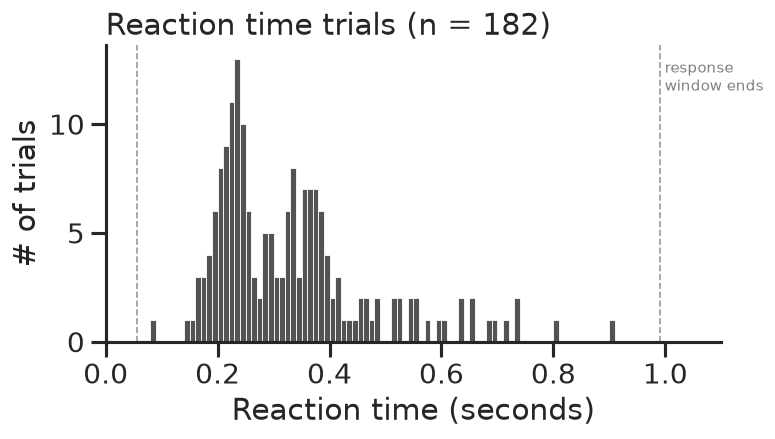

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_histogram.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_histogram.png'

In [8]:
RT_BIN_WIDTH = 0.01          # 10 ms
RT_AXIS_LIMITS = (0, 1.1)     # display range

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(x=reaction_time_array, binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]), color='k', edgecolor='white', linewidth=0.5, ax=ax)

ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')
ax.text(window_stop_offset.median(), ax.get_ylim()[1] * 0.95, ' response\n window ends', color='0.5', fontsize=9, va='top')

ax.set_xlim(*RT_AXIS_LIMITS)
ax.set_xlabel('Reaction time (seconds)')
ax.set_ylabel('# of trials')
ax.set_title('Reaction time trials (n = %d)' % (reaction_time_array.size))
sns.despine(ax=ax)
fig.tight_layout()
plt.show()
save_figure(fig, 'rt_histogram')

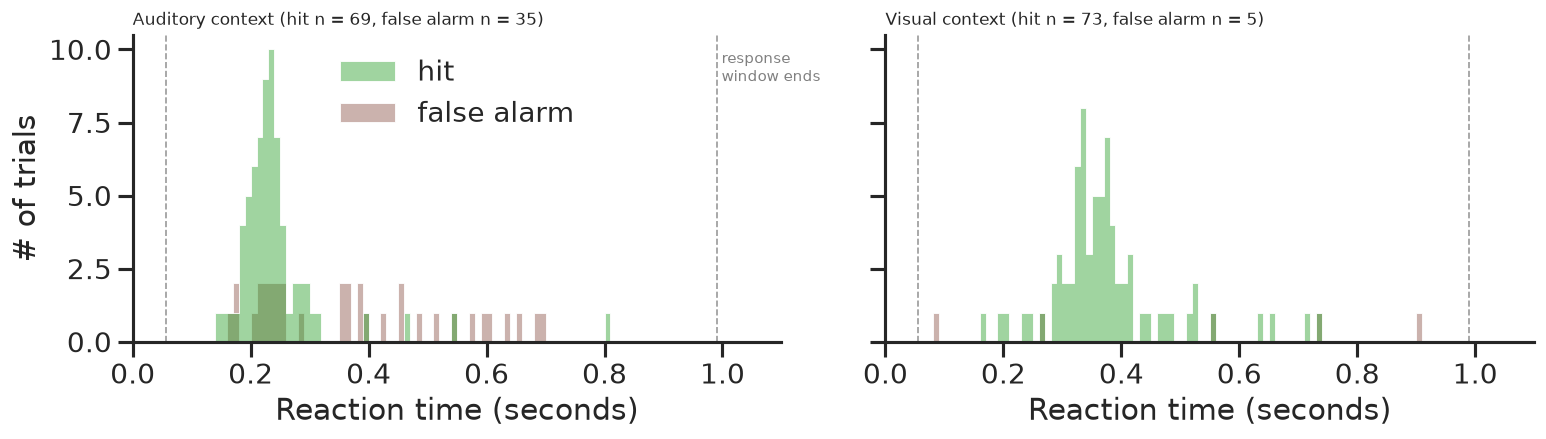

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_by_outcome_context.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_by_outcome_context.png'

In [9]:
OUTCOME_COLORS = {'hit': 'tab:green', 'false alarm': 'tab:brown'}
RT_OUTCOMES = ['hit', 'false alarm']
CONTEXT_PANELS = [('aud', 'Auditory context'), ('vis', 'Visual context')]

rt_by_outcome_context = trials[rt_trial_mask & trials.outcome.isin(RT_OUTCOMES) & trials.reaction_time.notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

for panel_index, (context_value, panel_title) in enumerate(CONTEXT_PANELS):
    ax = axes[panel_index]
    panel_data = rt_by_outcome_context[rt_by_outcome_context.rewarded_modality == context_value]

    sns.histplot(data=panel_data, x='reaction_time', hue='outcome',
                 hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                 binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]),
                 element='step', fill=True, alpha=0.45,
                 edgecolor='white', linewidth=0.5,
                 legend=(panel_index == 0), ax=ax)

    ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
    ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')

    ax.set_xlim(*RT_AXIS_LIMITS)
    ax.set_xlabel('Reaction time (seconds)')
    ax.set_title('%s (hit n = %d, false alarm n = %d)'
                 % (panel_title,
                    int((panel_data.outcome == 'hit').sum()),
                    int((panel_data.outcome == 'false alarm').sum())),
                 fontsize=10)
    sns.despine(ax=ax)

legend = axes[0].get_legend()
legend.set_title('')
legend.prop.set_size(8)
legend.get_frame().set_linewidth(0)

axes[0].set_ylabel('# of trials')
axes[1].set_ylabel('')
axes[0].text(window_stop_offset.median(), axes[0].get_ylim()[1] * 0.95, ' response\n window ends', color='0.5', fontsize=9, va='top')
fig.tight_layout()
plt.show()
save_figure(fig, 'rt_by_outcome_context')

Visual stimuli discrimination requires more time to reach the brain than the auditory stimuli.Therefore, the reaction times are slower.

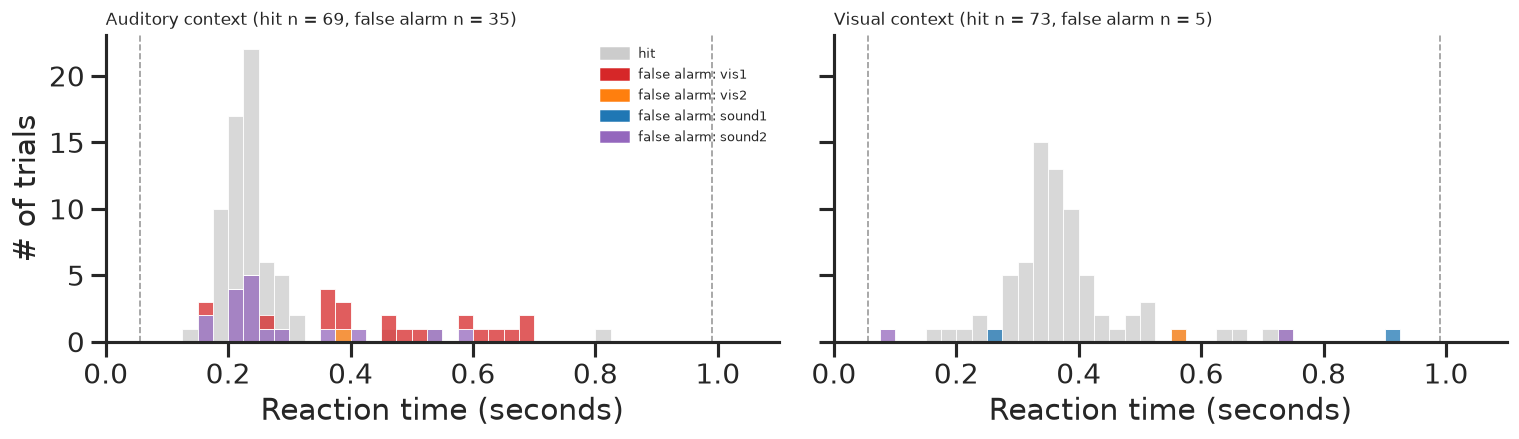

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_by_stim.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_by_stim.png'

In [10]:
RT_BIN_WIDTH_FA = 0.025       # coarser 25 ms
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange', 'sound1': 'tab:blue', 'sound2': 'tab:purple'}

false_alarm_trials = trials[rt_trial_mask & trials.is_false_alarm & trials.reaction_time.notna()]

fa_stim_present = [s for s in FA_STIM_COLORS if s in set(false_alarm_trials.stim_name)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

for panel_index, (context_value, panel_title) in enumerate(CONTEXT_PANELS):
    ax = axes[panel_index]
    panel_hits = trials[rt_trial_mask & trials.is_hit & (trials.rewarded_modality == context_value)]
    panel_fa = false_alarm_trials[false_alarm_trials.rewarded_modality == context_value]

    # hits as a grey backdrop, so the false alarms are the readable layer
    sns.histplot(x=panel_hits.reaction_time, binwidth=RT_BIN_WIDTH_FA,
                 binrange=(0, RT_AXIS_LIMITS[1]), color='0.8',
                 edgecolor='white', linewidth=0.5, ax=ax)
    sns.histplot(data=panel_fa, x='reaction_time', hue='stim_name',
                 hue_order=fa_stim_present, palette=FA_STIM_COLORS,
                 multiple='stack', binwidth=RT_BIN_WIDTH_FA,
                 binrange=(0, RT_AXIS_LIMITS[1]),
                 edgecolor='white', linewidth=0.5, legend=False, ax=ax)

    ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
    ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')
    ax.set_xlim(*RT_AXIS_LIMITS)
    ax.set_xlabel('Reaction time (seconds)')
    ax.set_title('%s (hit n = %d, false alarm n = %d)' % (panel_title, len(panel_hits), len(panel_fa)), fontsize=10)
    sns.despine(ax=ax)

legend_handles = ([Patch(color='0.8', label='hit')] + [Patch(color=FA_STIM_COLORS[s], label='false alarm: %s' % s) for s in fa_stim_present])
axes[0].legend(handles=legend_handles, fontsize=8, frameon=False, loc='upper right')

axes[0].set_ylabel('# of trials')
axes[1].set_ylabel('')
fig.tight_layout()
plt.show()
save_figure(fig, 'rt_by_stim')

False alarms reaction times are also related with the stimuli. Usually with longer reaction times.

REACTION TIME AND MOTIVATION ANALYSIS

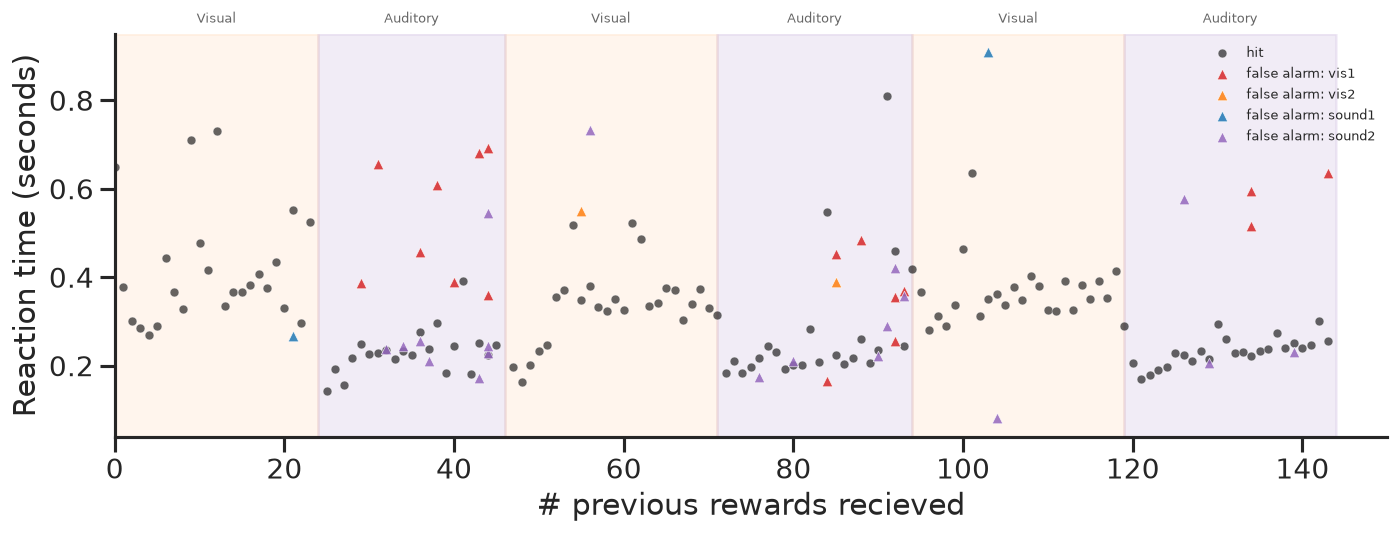

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_vs_previous_rewards.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_vs_previous_rewards.png'

In [11]:
trials['n_previous_rewards'] = trials.is_rewarded.cumsum().shift(1).fillna(0).astype(int)

rt_scatter_data = trials[rt_trial_mask & trials.outcome.isin(RT_OUTCOMES) & trials.reaction_time.notna()]

CONTEXT_SHADE = {'vis': ('tab:orange', 0.07), 'aud': ('tab:purple', 0.12)}
CONTEXT_LABELS = {'vis': 'Visual', 'aud': 'Auditory'}
HIT_COLOR = 'black'

fig, ax = plt.subplots(figsize=(12, 4.8))
block_summary = (trials.groupby('block_index')
                 .agg(band_start=('n_previous_rewards', 'min'),
                      band_stop=('n_previous_rewards', 'max'),
                      block_context=('rewarded_modality', 'first'))
                 .sort_index())
band_edges = list(block_summary.band_start) + [block_summary.band_stop.iloc[-1]]

for position, (block_index, block_row) in enumerate(block_summary.iterrows()):
    band_start = band_edges[position]
    band_stop = band_edges[position + 1]
    shade_color, shade_alpha = CONTEXT_SHADE[block_row.block_context]
    ax.axvspan(band_start, band_stop, color=shade_color, alpha=shade_alpha, zorder=0)
    ax.annotate(CONTEXT_LABELS[block_row.block_context],
                ((band_start + band_stop) / 2, 1.02),
                xycoords=('data', 'axes fraction'),
                ha='center', va='bottom', fontsize=8, color='0.4')

hit_data = rt_scatter_data[rt_scatter_data.outcome == 'hit']
ax.scatter(hit_data.n_previous_rewards, hit_data.reaction_time,
           s=28, alpha=0.6, marker='o', color=HIT_COLOR,
           edgecolor='white', linewidth=0.4, zorder=2, label='hit')

fa_data = rt_scatter_data[rt_scatter_data.outcome == 'false alarm']
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter(stim_subset.n_previous_rewards, stim_subset.reaction_time,
               s=40, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.4, zorder=3,
               label='false alarm: %s' % stim_name)

ax.set_xlabel('# previous rewards recieved')
ax.set_ylabel('Reaction time (seconds)')
ax.legend(fontsize=8, frameon=False, ncol=1, loc='upper right')
ax.set_xlim(0, 150)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()
save_figure(fig, 'rt_vs_previous_rewards')

Compute the consecutive rewarded or non-rewarded previous trials

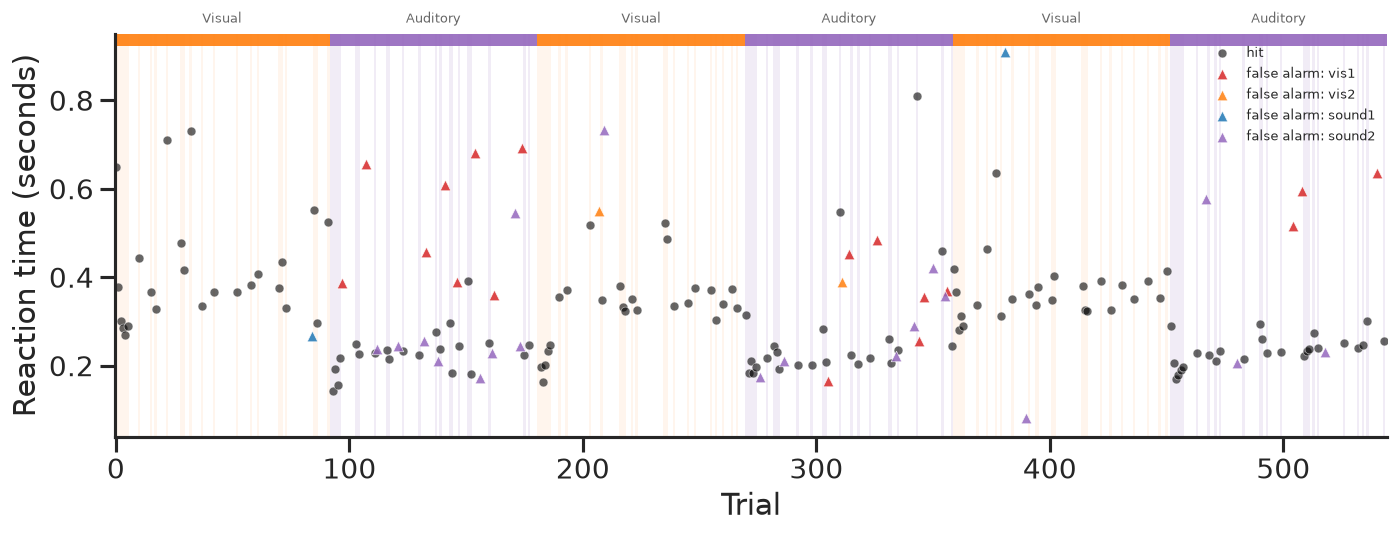

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_time.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_time.png'

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.8))

trial_position_by_id = {trial_id: position
                        for position, trial_id in enumerate(trials.index)}
block_index_array = trials.block_index.values
context_array = trials.rewarded_modality.values
rewarded_array = trials.is_rewarded.values

for trial_position in np.flatnonzero(rewarded_array):
    shade_color, shade_alpha = CONTEXT_SHADE[context_array[trial_position]]
    ax.axvspan(trial_position - 0.5, trial_position + 0.5,
               color=shade_color, alpha=shade_alpha, lw=0, zorder=0)

for block_index in np.unique(block_index_array):
    in_block = np.flatnonzero(block_index_array == block_index)
    first_position, last_position = in_block[0], in_block[-1]
    block_context = context_array[first_position]
    shade_color, _ = CONTEXT_SHADE[block_context]
    ax.axvspan(first_position - 0.5, last_position + 0.5,
               ymin=0.97, ymax=1.0, color=shade_color, alpha=0.9, lw=0, zorder=1)
    ax.annotate(CONTEXT_LABELS[block_context],
                ((first_position + last_position) / 2, 1.02),
                xycoords=('data', 'axes fraction'),
                ha='center', va='bottom', fontsize=8, color='0.4')

hit_data = rt_scatter_data[rt_scatter_data.outcome == 'hit']
ax.scatter([trial_position_by_id[i] for i in hit_data.index], hit_data.reaction_time,
           s=28, alpha=0.6, marker='o', color=HIT_COLOR,
           edgecolor='white', linewidth=0.4, zorder=2, label='hit')

fa_data = rt_scatter_data[rt_scatter_data.outcome == 'false alarm']
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter([trial_position_by_id[i] for i in stim_subset.index],
               stim_subset.reaction_time,
               s=40, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.4, zorder=3,
               label='false alarm: %s' % stim_name)

ax.set_xlabel('Trial')
ax.set_ylabel('Reaction time (seconds)')
ax.legend(fontsize=8, frameon=False, ncol=1, loc='upper right')
ax.set_xlim(-0.5, len(trials) - 0.5)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()
save_figure(fig, 'rt_time')

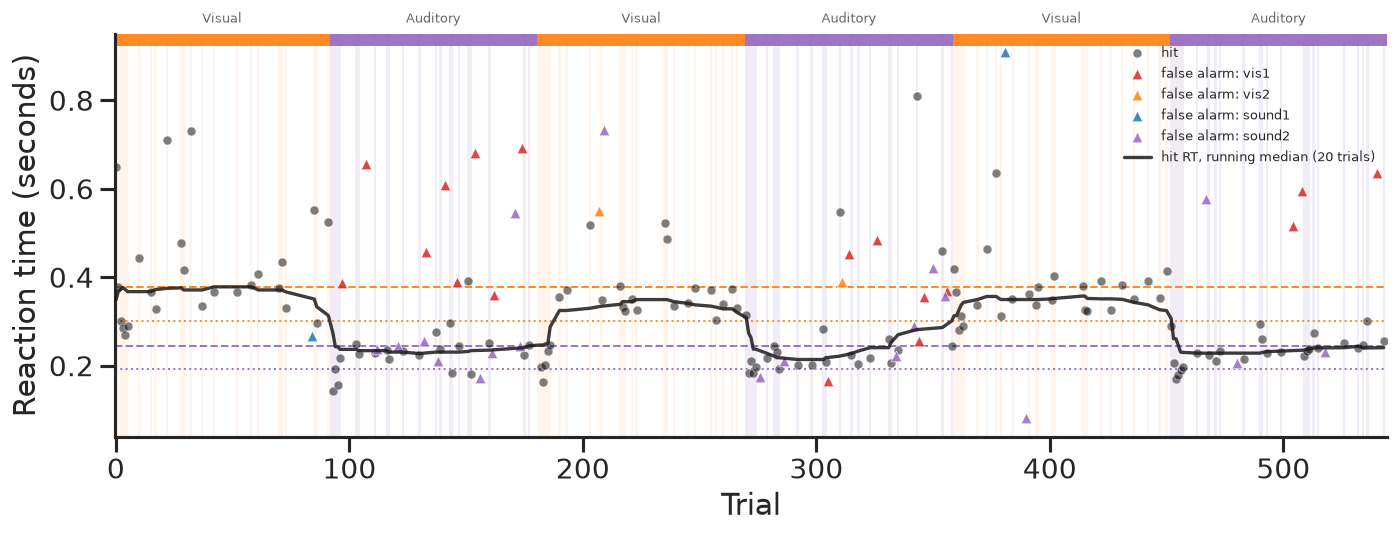

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_time_fit.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_time_fit.png'

In [13]:
BASELINE_BLOCKS = [0, 1]
START_BASELINE_N = 5       # hits at the start of each block
END_BASELINE_N = 10        # hits at the end of each block
RUNNING_WINDOW = 20        # hits in the running median

fig, ax = plt.subplots(figsize=(12, 4.8))

trial_position_by_id = {trial_id: position for position, trial_id in enumerate(trials.index)}
block_index_array = trials.block_index.values
context_array = trials.rewarded_modality.values
rewarded_array = trials.is_rewarded.values

for trial_position in np.flatnonzero(rewarded_array):
    shade_color, shade_alpha = CONTEXT_SHADE[context_array[trial_position]]
    ax.axvspan(trial_position - 0.5, trial_position + 0.5,
               color=shade_color, alpha=shade_alpha, lw=0, zorder=0)

for block_index in np.unique(block_index_array):
    in_block = np.flatnonzero(block_index_array == block_index)
    first_position, last_position = in_block[0], in_block[-1]
    block_context = context_array[first_position]
    shade_color, _ = CONTEXT_SHADE[block_context]
    ax.axvspan(first_position - 0.5, last_position + 0.5,
               ymin=0.97, ymax=1.0, color=shade_color, alpha=0.9, lw=0, zorder=1)
    ax.annotate(CONTEXT_LABELS[block_context],
                ((first_position + last_position) / 2, 1.02),
                xycoords=('data', 'axes fraction'),
                ha='center', va='bottom', fontsize=8, color='0.4')

hit_data = rt_scatter_data[rt_scatter_data.outcome == 'hit']
hit_position = np.array([trial_position_by_id[i] for i in hit_data.index])
ax.scatter(hit_position, hit_data.reaction_time,
           s=28, alpha=0.5, marker='o', color=HIT_COLOR,
           edgecolor='white', linewidth=0.4, zorder=2, label='hit')

fa_data = rt_scatter_data[rt_scatter_data.outcome == 'false alarm']
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter([trial_position_by_id[i] for i in stim_subset.index],
               stim_subset.reaction_time,
               s=40, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.4, zorder=3,
               label='false alarm: %s' % stim_name)

running_median = pd.Series(hit_data.reaction_time.values).rolling(RUNNING_WINDOW, min_periods=5, center=True).median().values
ax.plot(hit_position, running_median, color='k', lw=2, alpha=0.85, zorder=4, label='hit RT, running median (%d trials)' % RUNNING_WINDOW)

for block_index in BASELINE_BLOCKS:
    block_hits = hit_data[hit_data.block_index == block_index]
    if len(block_hits) < 2:
        continue
    block_rt = block_hits.reaction_time.values
    block_context = context_array[trial_position_by_id[block_hits.index[0]]]
    line_color = CONTEXT_SHADE[block_context][0]

    n_start = min(START_BASELINE_N, len(block_rt))
    n_end = min(END_BASELINE_N, len(block_rt))
    start_level = np.median(block_rt[:n_start])
    end_level = np.median(block_rt[-n_end:])

    ax.axhline(start_level, color=line_color, lw=1.2, ls=':', alpha=0.9, zorder=1)
    ax.axhline(end_level, color=line_color, lw=1.2, ls='--', alpha=0.9, zorder=1)

ax.set_xlabel('Trial')
ax.set_ylabel('Reaction time (seconds)')
ax.legend(fontsize=8, frameon=False, ncol=1, loc='upper right')
ax.set_xlim(-0.5, len(trials) - 0.5)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()
save_figure(fig, 'rt_time_fit')

Rewarded and non-rewarded streak

In [14]:
def trailing_streak(flag_array):
    """Number of consecutive True values immediately preceding each position."""
    streak = np.zeros(len(flag_array), dtype=int)
    run_length = 0
    for position, flag in enumerate(flag_array):
        streak[position] = run_length
        run_length = run_length + 1 if flag else 0
    return streak

trials['consecutive_rewarded'] = trailing_streak(trials.is_rewarded.values)
trials['consecutive_unrewarded'] = trailing_streak(~trials.is_rewarded.values)

streak_data = trials[rt_trial_mask & trials.reaction_time.notna()].copy()

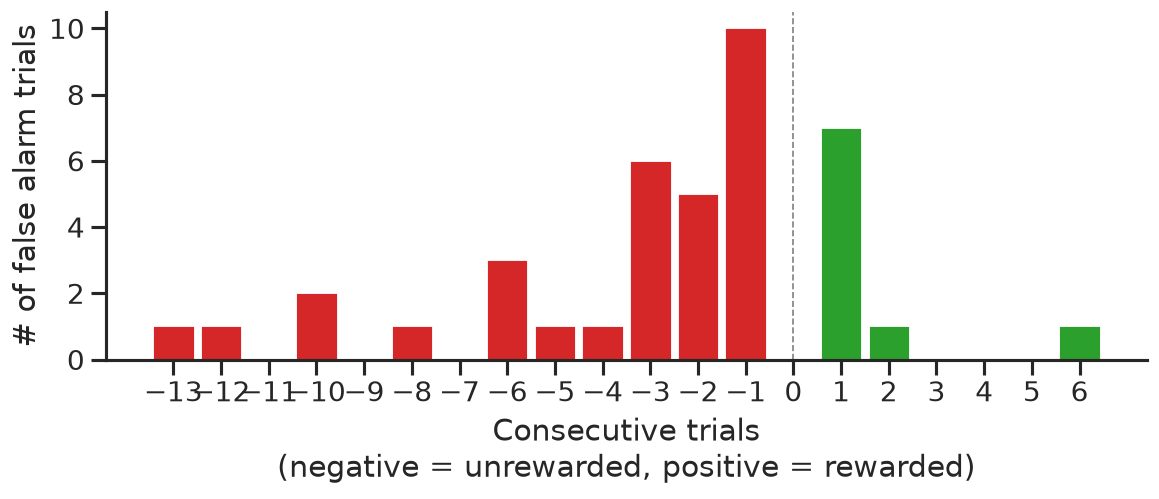

saved /scratch/rt_analysis/figures/759434_2025-02-04__false_alarms.png


'/scratch/rt_analysis/figures/759434_2025-02-04__false_alarms.png'

In [15]:
FA_STREAK_COLORS = {'negative': 'tab:red', 'positive': 'tab:green'}

false_alarm_streak = streak_data[streak_data.outcome == 'false alarm'].copy()

false_alarm_streak['signed_streak'] = np.where(false_alarm_streak.consecutive_rewarded > 0, false_alarm_streak.consecutive_rewarded, -false_alarm_streak.consecutive_unrewarded)

streak_min = int(false_alarm_streak.signed_streak.min())
streak_max = int(false_alarm_streak.signed_streak.max())
bin_edges = np.arange(streak_min - 0.5, streak_max + 1.5, 1)

fig, ax = plt.subplots(figsize=(10, 4.5))
counts, _ = np.histogram(false_alarm_streak.signed_streak, bins=bin_edges)
bin_centers = bin_edges[:-1] + 0.5
bar_colors = [FA_STREAK_COLORS['negative'] if c < 0 else FA_STREAK_COLORS['positive'] for c in bin_centers]

ax.bar(bin_centers, counts, width=0.85, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='0.5', lw=1, ls='--')

ax.set_xlabel('Consecutive trials\n' '(negative = unrewarded, positive = rewarded)')
ax.set_ylabel('# of false alarm trials')
ax.set_xticks(np.arange(streak_min, streak_max + 1))
sns.despine(ax=ax)
fig.tight_layout()
plt.show()
save_figure(fig, 'false_alarms')

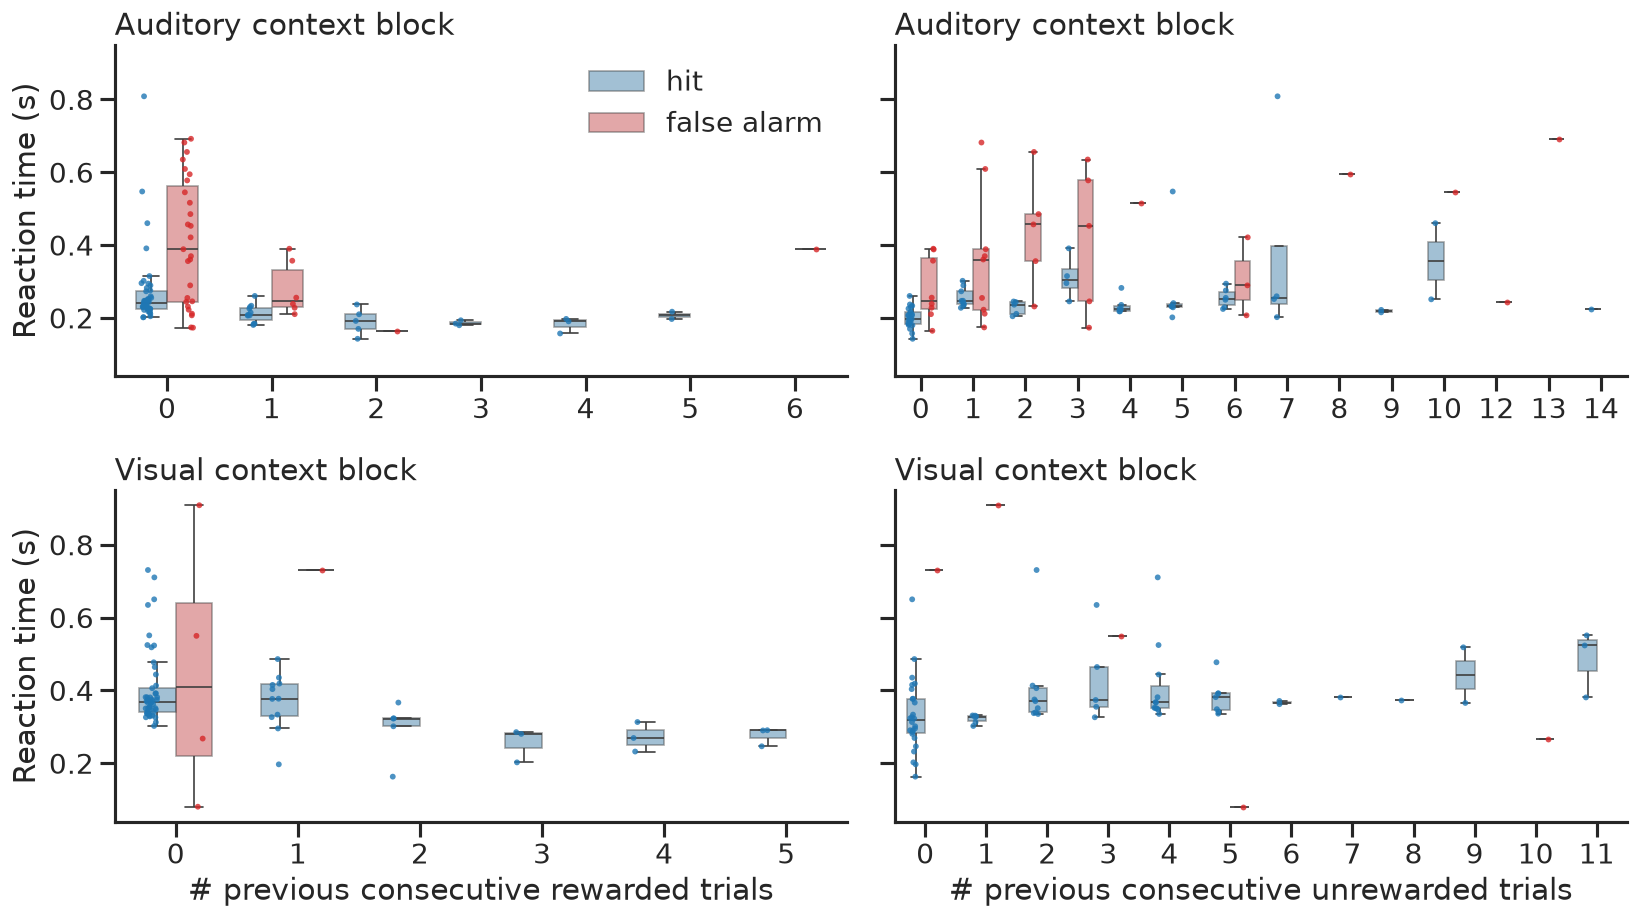

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_consecutive.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_consecutive.png'

In [16]:
CONTEXT_ROWS = [('aud', 'Auditory'), ('vis', 'Visual')]
STREAK_COLUMNS = [('consecutive_rewarded', '# previous consecutive rewarded trials'), ('consecutive_unrewarded', '# previous consecutive unrewarded trials')]
OUTCOME_COLORS = {'hit': 'tab:blue', 'false alarm': 'tab:red'}
RT_OUTCOMES = ['hit', 'false alarm']

streak_outcome_data = streak_data[streak_data.outcome.isin(RT_OUTCOMES)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

for row_index, (context_value, context_label) in enumerate(CONTEXT_ROWS):
    for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
        ax = axes[row_index, col_index]
        panel_data = streak_outcome_data[
            streak_outcome_data.rewarded_modality == context_value]
        level_order = sorted(panel_data[streak_column].unique())

        sns.boxplot(data=panel_data, x=streak_column, y='reaction_time',
                    hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                    order=level_order, width=0.6, showfliers=False, linewidth=1,
                    boxprops={'alpha': 0.45},
                    legend=(row_index == 0 and col_index == 0), ax=ax)
        sns.stripplot(data=panel_data, x=streak_column, y='reaction_time',
                      hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                      order=level_order, dodge=True, size=3.5, alpha=0.8,
                      linewidth=0, legend=False, ax=ax)

        ax.set_title('%s context block' % (context_label), fontsize=18)
        ax.set_xlabel(column_label if row_index == 1 else '')
        ax.set_ylabel('Reaction time (s)' if col_index == 0 else '')
        sns.despine(ax=ax)

legend = axes[0, 0].get_legend()
if legend is not None:
    legend.set_title('')
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)

fig.tight_layout()
plt.show()
save_figure(fig, 'rt_consecutive')

Auditory, # previous consecutive rewarded trials, hit: slope -28.9 ms/trial (SE 9.8), r² = 0.117, p = 0.0046, n = 67
Auditory, # previous consecutive rewarded trials, false alarm: slope -126.3 ms/trial (SE 55.3), r² = 0.140, p = 0.029, n = 34
Auditory, # previous consecutive unrewarded trials, hit: slope +10.9 ms/trial (SE 3.2), r² = 0.169, p = 0.0011, n = 60
Auditory, # previous consecutive unrewarded trials, false alarm: slope +12.6 ms/trial (SE 15.9), r² = 0.021, p = 0.43, n = 31
Visual, # previous consecutive rewarded trials, hit: slope -41.4 ms/trial (SE 10.4), r² = 0.188, p = 0.00018, n = 70
Visual, # previous consecutive rewarded trials, false alarm: n = 5 < 20, skipped
Visual, # previous consecutive unrewarded trials, hit: slope +14.8 ms/trial (SE 6.3), r² = 0.080, p = 0.021, n = 66
Visual, # previous consecutive unrewarded trials, false alarm: n = 4 < 20, skipped


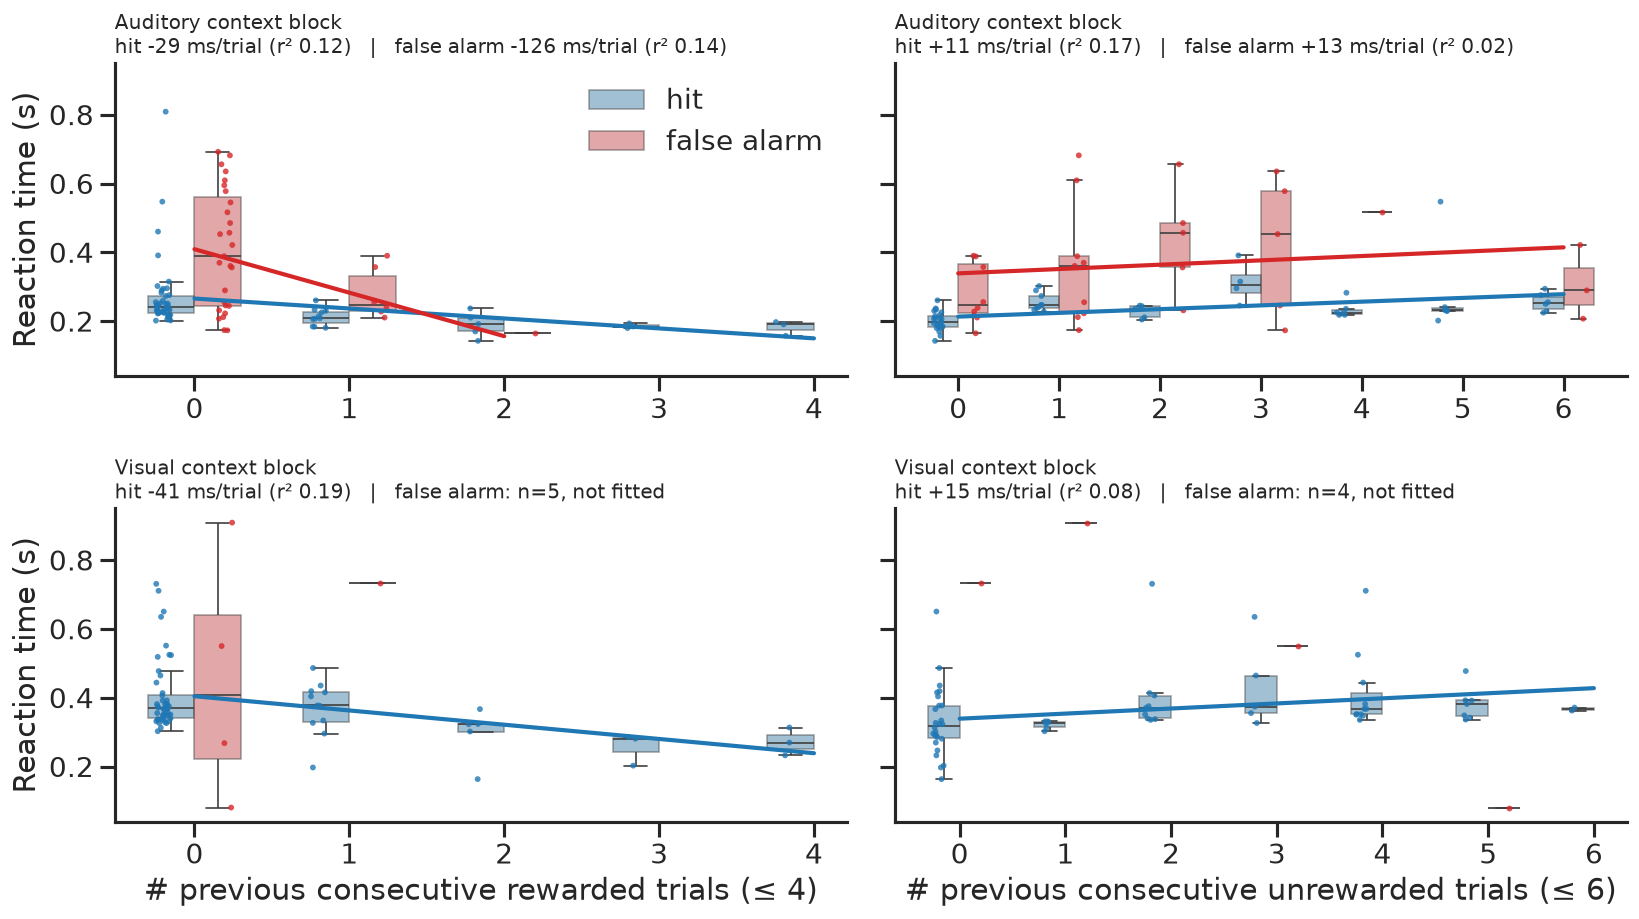

saved /scratch/rt_analysis/figures/759434_2025-02-04__rt_consecutive_slopes.png


'/scratch/rt_analysis/figures/759434_2025-02-04__rt_consecutive_slopes.png'

In [17]:
MIN_TRIALS_FOR_FIT = 20        # skip regressions with fewer trials than this
MAX_STREAK_LEVEL = {'consecutive_rewarded': 4, 'consecutive_unrewarded': 6}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

for row_index, (context_value, context_label) in enumerate(CONTEXT_ROWS):
    for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
        ax = axes[row_index, col_index]
        max_level = MAX_STREAK_LEVEL[streak_column]
        panel_data = streak_outcome_data[
            (streak_outcome_data.rewarded_modality == context_value)
            & (streak_outcome_data[streak_column] <= max_level)]
        level_order = sorted(panel_data[streak_column].unique())

        sns.boxplot(data=panel_data, x=streak_column, y='reaction_time',
                    hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                    order=level_order, width=0.6, showfliers=False, linewidth=1,
                    boxprops={'alpha': 0.45},
                    legend=(row_index == 0 and col_index == 0), ax=ax)
        sns.stripplot(data=panel_data, x=streak_column, y='reaction_time',
                      hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                      order=level_order, dodge=True, size=3.5, alpha=0.8,
                      linewidth=0, legend=False, ax=ax)

        position_by_level = {level: position for position, level in enumerate(level_order)}
        title_parts = []
        for outcome_label in RT_OUTCOMES:
            outcome_data = panel_data[panel_data.outcome == outcome_label]
            x = outcome_data[streak_column].map(position_by_level).values.astype(float)
            y = outcome_data.reaction_time.values.astype(float)

            if len(x) < MIN_TRIALS_FOR_FIT or len(np.unique(x)) < 2:
                title_parts.append('%s: n=%d, not fitted' % (outcome_label, len(x)))
                print('%s, %s, %s: n = %d < %d, skipped'
                      % (context_label, column_label, outcome_label,
                         len(x), MIN_TRIALS_FOR_FIT))
                continue

            result = linregress(x, y)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, result.intercept + result.slope * x_line,
                    color=OUTCOME_COLORS[outcome_label], lw=2.5, zorder=5)
            title_parts.append('%s %+.0f ms/trial (r\u00b2 %.2f)'
                               % (outcome_label, result.slope * 1e3, result.rvalue ** 2))
            print('%s, %s, %s: slope %+.1f ms/trial (SE %.1f), r\u00b2 = %.3f, '
                  'p = %.2g, n = %d'
                  % (context_label, column_label, outcome_label,
                     result.slope * 1e3, result.stderr * 1e3,
                     result.rvalue ** 2, result.pvalue, len(x)))

        ax.set_title('%s context block\n%s' % (context_label, '   |   '.join(title_parts)), fontsize=12)
        ax.set_xlabel('%s (\u2264 %d)' % (column_label, max_level) if row_index == 1 else '')
        ax.set_ylabel('Reaction time (s)' if col_index == 0 else '')
        sns.despine(ax=ax)

legend = axes[0, 0].get_legend()
if legend is not None:
    legend.set_title('')
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)

fig.tight_layout()
plt.show()
save_figure(fig, 'rt_consecutive_slopes')

SUMMARY SAVE

In [18]:
# Save trial variables
TRIAL_EXPORT_COLUMNS = [
    'trial_index', 'block_index', 'rewarded_modality', 'stim_name', 'outcome',
    'start_time', 'stop_time', 'stim_start_time', 'stim_stop_time',
    'response_window_start_time', 'response_window_stop_time',
    'response_time', 'reward_time', 'reaction_time',
    'is_response', 'is_hit', 'is_miss', 'is_false_alarm', 'is_correct_reject',
    'is_go', 'is_nogo', 'is_catch', 'is_rewarded', 'is_contingent_reward',
    'is_noncontingent_reward', 'is_instruction', 'is_repeat', 'is_opto',
    'is_target', 'is_nontarget', 'is_aud_stim', 'is_vis_stim',
    'consecutive_rewarded', 'consecutive_unrewarded', 'n_previous_rewards',
]
trial_export = trials[[c for c in TRIAL_EXPORT_COLUMNS if c in trials]].copy()
trial_export['trial_position'] = np.arange(len(trial_export))
trial_export['in_rt_analysis'] = rt_trial_mask.values      # responded, non-catch
save_table(trial_export, 'trials')

# Save RT data
level_rows = []
for context_value, context_label in CONTEXT_ROWS:
    for streak_column, column_label in STREAK_COLUMNS:
        panel_data = streak_outcome_data[streak_outcome_data.rewarded_modality == context_value]
        for outcome_label in RT_OUTCOMES:
            outcome_data = panel_data[panel_data.outcome == outcome_label]
            for level_value, level_group in outcome_data.groupby(streak_column):
                rt_values = level_group.reaction_time
                level_rows.append({
                    'context': context_value,
                    'streak': streak_column,
                    'outcome': outcome_label,
                    'streak_level': int(level_value),
                    'n_trials': len(rt_values),
                    'rt_median': rt_values.median(),
                    'rt_mean': rt_values.mean(),
                    'rt_std': rt_values.std(),
                    'rt_q25': rt_values.quantile(0.25),
                    'rt_q75': rt_values.quantile(0.75),
                    'rt_min': rt_values.min(),
                    'rt_max': rt_values.max()})
save_table(pd.DataFrame(level_rows), 'rt_streak_levels')

# Save RT fits data
rt_slope_rows = []
for context_value, context_label in CONTEXT_ROWS:
    for streak_column, column_label in STREAK_COLUMNS:
        for cap_label, max_level in [('uncapped', np.inf), ('capped', MAX_STREAK_LEVEL[streak_column])]:
            panel_data = streak_outcome_data[
                (streak_outcome_data.rewarded_modality == context_value) & (streak_outcome_data[streak_column] <= max_level)]
            for outcome_label in RT_OUTCOMES:
                outcome_data = panel_data[panel_data.outcome == outcome_label]
                x = outcome_data[streak_column].values.astype(float)
                y = outcome_data.reaction_time.values.astype(float)
                if len(x) < MIN_TRIALS_FOR_FIT or len(np.unique(x)) < 2:
                    continue
                result = linregress(x, y)
                rt_slope_rows.append({
                    'context': context_value,
                    'streak': streak_column,
                    'outcome': outcome_label,
                    'cap': cap_label,
                    'max_level': (np.nan if np.isinf(max_level) else int(max_level)),
                    'slope_ms_per_trial': result.slope * 1e3,
                    'slope_se_ms': result.stderr * 1e3,
                    'intercept_ms': result.intercept * 1e3,
                    'slope_std': (result.slope * x.std() / y.std() if y.std() > 0 else np.nan),
                    'r2': result.rvalue ** 2,
                    'p': result.pvalue,
                    'n': len(x)})
save_table(pd.DataFrame(rt_slope_rows), 'rt_streak_slopes')

# Save RT blocks data
block_rows = []
for block_index in np.unique(trials.block_index.values):
    block_trials = trials[trials.block_index == block_index]
    block_hits = block_trials[rt_trial_mask & (trials.outcome == 'hit')
                              & trials.reaction_time.notna()
                              & (trials.block_index == block_index)]
    row = {'block_index': int(block_index),
           'context': block_trials.rewarded_modality.iloc[0],
           'n_trials': len(block_trials),
           'n_hits': len(block_hits),
           'first_trial_position': int(np.flatnonzero(trials.block_index.values == block_index)[0]),
           'last_trial_position': int(np.flatnonzero(trials.block_index.values == block_index)[-1])}
    if len(block_hits) >= 10:
        y = block_hits.reaction_time.values
        result = linregress(np.arange(len(y), dtype=float), y)
        row.update({'rt_median': np.median(y),
                    'rt_first5_median': np.median(y[:5]),
                    'rt_last10_median': np.median(y[-10:]),
                    'slope_ms_per_trial': result.slope * 1e3,
                    'slope_se_ms': result.stderr * 1e3,
                    'intercept_ms': result.intercept * 1e3,
                    'r2': result.rvalue ** 2,
                    'p': result.pvalue})
    block_rows.append(row)
save_table(pd.DataFrame(block_rows), 'block_fits')

# Save data
metric_rows = []

def add_metric(name, value):
    metric_rows.append({'metric': name, 'value': value})

add_metric('n_trials', len(trials))
add_metric('n_go', int(trials.is_go.sum()))
add_metric('n_nogo', int(trials.is_nogo.sum()))
add_metric('n_catch', int(trials.is_catch.sum()))
add_metric('n_blocks', int(trials.block_index.nunique()))
add_metric('hit_rate', trials.is_hit.sum() / max(trials.is_go.sum(), 1))
add_metric('false_alarm_rate', trials.is_false_alarm.sum() / max(trials.is_nogo.sum(), 1))
add_metric('n_miss', int(trials.is_miss.sum()))
add_metric('n_rewarded', int(trials.is_rewarded.sum()))

responded = trials[rt_trial_mask & trials.reaction_time.notna()]
add_metric('n_responded', len(responded))
add_metric('rt_median_all', responded.reaction_time.median())
add_metric('rt_q25_all', responded.reaction_time.quantile(0.25))
add_metric('rt_q75_all', responded.reaction_time.quantile(0.75))
for outcome_label in RT_OUTCOMES:
    outcome_rt = responded[responded.outcome == outcome_label].reaction_time
    key = outcome_label.replace(' ', '_')
    add_metric('rt_median_%s' % key, outcome_rt.median())
    add_metric('n_%s' % key, len(outcome_rt))
for context_value in ['aud', 'vis']:
    context_rt = responded[responded.rewarded_modality == context_value].reaction_time
    add_metric('rt_median_%s' % context_value, context_rt.median())
    add_metric('n_%s' % context_value, len(context_rt))

for streak_column, streak_label in STREAK_COLUMNS:
    hit_subset = responded[(responded.outcome == 'hit') & (responded[streak_column] <= MAX_STREAK_LEVEL[streak_column])]
    if len(hit_subset) >= MIN_TRIALS_FOR_FIT:
        result = linregress(hit_subset[streak_column].values.astype(float), hit_subset.reaction_time.values)
        key = streak_column.replace('consecutive_', '')
        add_metric('rt_slope_%s_ms' % key, result.slope * 1e3)
        add_metric('rt_slope_%s_se_ms' % key, result.stderr * 1e3)
        add_metric('rt_slope_%s_p' % key, result.pvalue)
        add_metric('rt_slope_%s_n' % key, len(hit_subset))

# Analyis of the statistics
add_metric('min_trials_for_fit', MIN_TRIALS_FOR_FIT)
add_metric('max_level_rewarded', MAX_STREAK_LEVEL['consecutive_rewarded'])
add_metric('max_level_unrewarded', MAX_STREAK_LEVEL['consecutive_unrewarded'])

session_metrics = pd.DataFrame(metric_rows)
save_table(session_metrics, 'session_metrics')

saved /scratch/rt_analysis/data/759434_2025-02-04__trials.csv
saved /scratch/rt_analysis/data/759434_2025-02-04__rt_streak_levels.csv
saved /scratch/rt_analysis/data/759434_2025-02-04__rt_streak_slopes.csv
saved /scratch/rt_analysis/data/759434_2025-02-04__block_fits.csv
saved /scratch/rt_analysis/data/759434_2025-02-04__session_metrics.csv


/tmp/ipykernel_55541/1218023981.py:75: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  block_hits = block_trials[rt_trial_mask & (trials.outcome == 'hit')
/tmp/ipykernel_55541/1218023981.py:75: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  block_hits = block_trials[rt_trial_mask & (trials.outcome == 'hit')
/tmp/ipykernel_55541/1218023981.py:75: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  block_hits = block_trials[rt_trial_mask & (trials.outcome == 'hit')
/tmp/ipykernel_55541/1218023981.py:75: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  block_hits = block_trials[rt_trial_mask & (trials.outcome == 'hit')
/tmp/ipykernel_55541/1218023981.py:75: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  block_hits = block_trials[rt_trial_mask & (trials.outcome == 'hit')
/tmp/ipykernel_55541/1218023981.py:75: UserWarning: Boolean Series key will

'/scratch/rt_analysis/data/759434_2025-02-04__session_metrics.csv'